In [1]:
import pandas as pd
import numpy as np 

df = pd.read_csv("contextual_bandit_dataset.csv")
N,d =df.shape
print(N,d)

8000 13


In [2]:
categorical_cols = ['gender','device','region','time_of_day'] #hot coding yapacağımız satırlar
df_processed = pd.get_dummies(df,columns = categorical_cols,drop_first=True) # ilkini düşüryoruz ve hepsinin 0 oldupu durumda o olduğu otomatik oalrak anlaşılıyor
boolean_cols = df_processed.select_dtypes(include=['bool']).columns 
df_processed[boolean_cols] = df_processed[boolean_cols].astype(int)
df_processed.to_csv("processed_data.csv")
df_processed.to_excel("processed_excel.xlsx")

In [3]:
numeric_cols = [
    'age',
    'session_count',
    'avg_purchase'
]
categorical_encoded_cols = [
    'gender_M',
    'device_mobile',
    'device_tablet',
    'region_dogu_anadolu',
    'region_ege',
    'region_guneydogu_anadolu',
    'region_ic_anadolu',
    'region_karadeniz',
    'region_marmara',
    'time_of_day_evening',
    'time_of_day_morning',
    'time_of_day_night'
]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_processed[numeric_cols] = scaler.fit_transform(df_processed[numeric_cols])

In [5]:
reward_cols = [
    'reward_arm_0',
    'reward_arm_1',
    'reward_arm_2',
    'reward_arm_3',
    'reward_arm_4'
]

rewards = df_processed[reward_cols].values

In [6]:
feature_cols = []

for col in df_processed.columns:
    if col not in reward_cols and col != 'user_id':
        feature_cols.append(col)

X = df_processed[feature_cols].values # bizim featurelarımızı tutan bşr numpy array

In [7]:
n_features = X.shape[1] # (8000,15) [1] -> diyince feature sayısını almış oluruz
n_arms = len(reward_cols) # kaç elemanlı olduğunu döndürür 5 tane reward column var

In [8]:

A = [] # a listesi içerisinde her arm için bir matris bulunduracak
for i in range(n_arms):
    matrix = np.eye(n_features)
    A.append(matrix)

b = [] # b listesi içerisinde vektörler olacak
for i in range(n_arms):
    vector = np.zeros(n_features)
    b.append(vector)

In [9]:
x = X[0]
print(x)
print(x.shape)
print(A[1])
print(b[1])

[ 0.7838605  -0.0752611  -0.07203111  0.          0.          1.
  0.          0.          0.          0.          0.          1.
  0.          0.          0.        ]
(15,)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [10]:
alpha = 1 #belirsizliğe ne kadar önem vereceğiz
chosen_arms = [] # algoritmanın hangi kullanıcı da hangi reklamı reçtiğini tutacak
obtained_rewards = [] # seçtiğimiz reklamların rewardlarını tutacak

for i in range(len(X)): # bütün kullanıcıları tek tek dolaş 

    x = X[i]

    scores = [] # puanlar için boş liste // scores = [0.52, 0.71, 1.24, 0.33, 0.61] gibi

    for arm in range(n_arms): # reklamların hepsini tek tek deniyoruz

        theta = np.linalg.solve(A[arm], b[arm]) # armın thetasını hesapla

        prediction = np.dot(x, theta) # iç çarpım yapıyor

        A_inv = np.linalg.inv(A[arm]) # a matrisinin tersini hesaplama

        uncertainty_value = np.dot(x, np.dot(A_inv, x)) #Anın tersiyle xin iç çarpımını yapıp bununla da xin iç çarpımını yapar

        uncertainty = np.sqrt(uncertainty_value)

        score = prediction + alpha * uncertainty # her arm için hesaplar scoresa ekler

        scores.append(score)

    chosen_arm = np.argmax(scores) #listedeki en büyük sayının indexini verir

    reward = rewards[i, chosen_arm] # rewardı alıp tahmin iyi mi diye test eder

    A[chosen_arm] = A[chosen_arm] + np.outer(x, x) # seçilen armın karşılatığı context bilgisini biriktirir

    b[chosen_arm] = b[chosen_arm] + reward * x # seçilen armın context bilgisini seçilen arm ile birlikte günceller

    chosen_arms.append(chosen_arm)
    obtained_rewards.append(reward)


In [11]:
print("Toplam kullanıcı:", len(X))
print("Toplam reward:", sum(obtained_rewards))
print("Ortalama reward:", np.mean(obtained_rewards))

Toplam kullanıcı: 8000
Toplam reward: 2997
Ortalama reward: 0.374625


In [12]:
print("X:", X.shape)
print("rewards:", rewards.shape)
print("chosen_arms:", len(chosen_arms))
print("obtained_rewards:", len(obtained_rewards))

X: (8000, 15)
rewards: (8000, 5)
chosen_arms: 8000
obtained_rewards: 8000


In [13]:
for arm in range(n_arms):

    selected = np.array(chosen_arms) == arm #seçilen arma eşir olanlar true diğerleri flase olur

    total_selected = np.sum(selected) #true false değerlerini topluyoruz

    total_reward = np.sum(np.array(obtained_rewards)[selected]) # obtained rewardları 1 olanları topla

    reward_rate = total_reward / total_selected # başarı oranı hesaplarız

    print("Arm ",arm)
    print("Seçilme:", total_selected)
    print("Reward:", total_reward)
    print("Başarı oranı:", reward_rate)

Arm  0
Seçilme: 2283
Reward: 1011
Başarı oranı: 0.442838370565046
Arm  1
Seçilme: 993
Reward: 273
Başarı oranı: 0.27492447129909364
Arm  2
Seçilme: 3136
Reward: 1311
Başarı oranı: 0.4180484693877551
Arm  3
Seçilme: 1014
Reward: 301
Başarı oranı: 0.2968441814595661
Arm  4
Seçilme: 574
Reward: 101
Başarı oranı: 0.1759581881533101


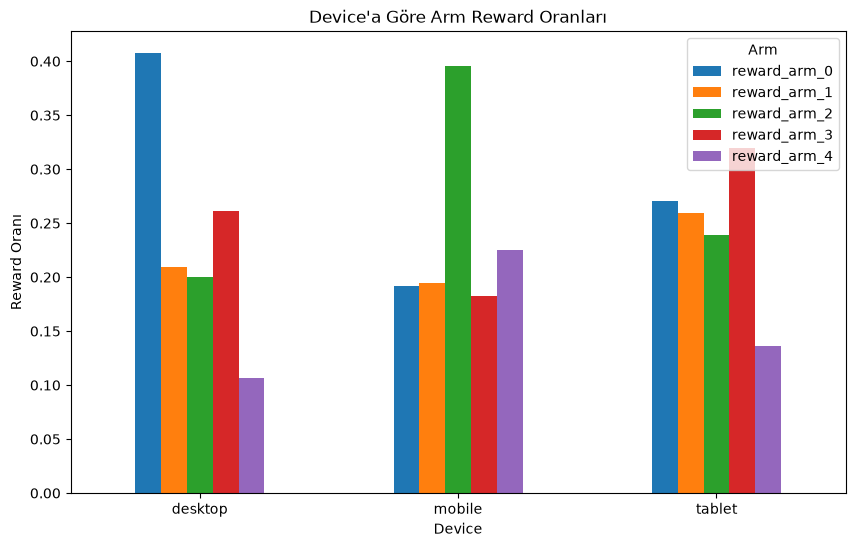

In [14]:
import matplotlib.pyplot as plt

device_reward = df.groupby("device")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

device_reward.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Device")
plt.ylabel("Reward Oranı")
plt.title("Device'a Göre Arm Reward Oranları")
plt.xticks(rotation=0)
plt.legend(title="Arm")

plt.show()

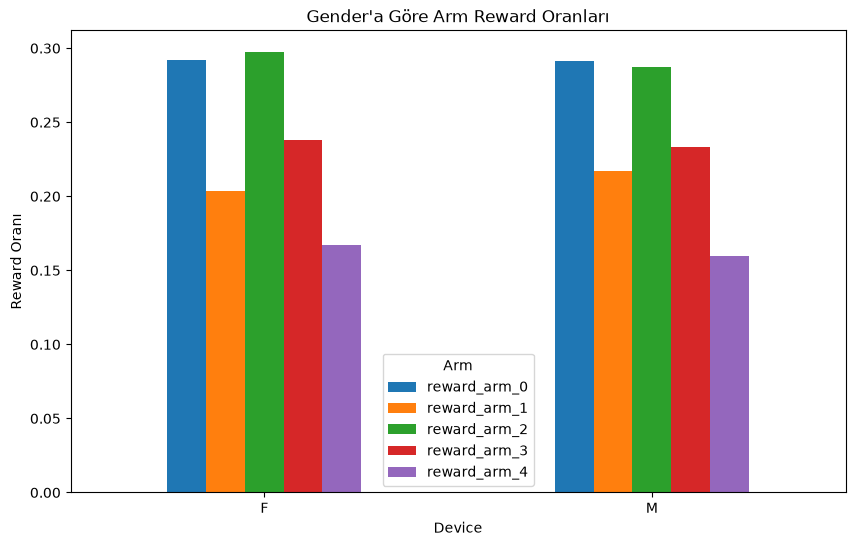

In [15]:
device_reward = df.groupby("gender")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

device_reward.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Device")
plt.ylabel("Reward Oranı")
plt.title("Gender'a Göre Arm Reward Oranları")
plt.xticks(rotation=0)
plt.legend(title="Arm")

plt.show()

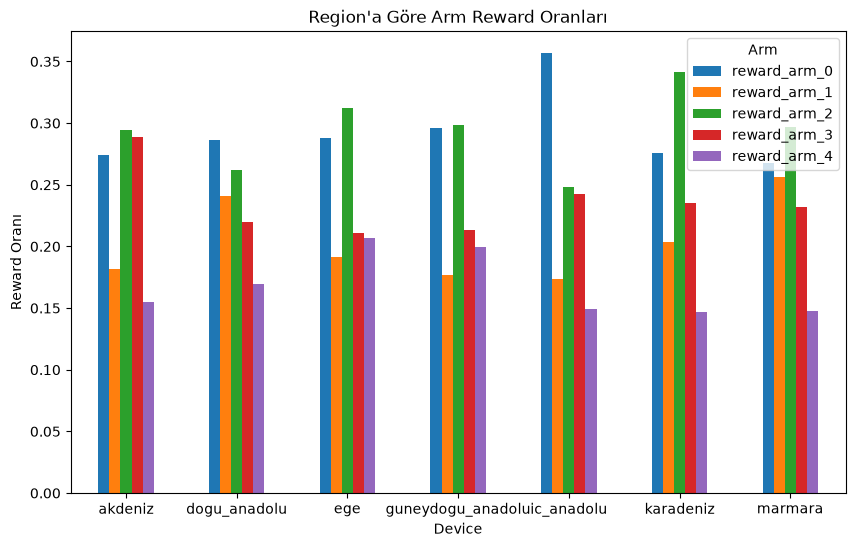

In [16]:
device_reward = df.groupby("region")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

device_reward.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Device")
plt.ylabel("Reward Oranı")
plt.title("Region'a Göre Arm Reward Oranları")
plt.xticks(rotation=0)
plt.legend(title="Arm")

plt.show()

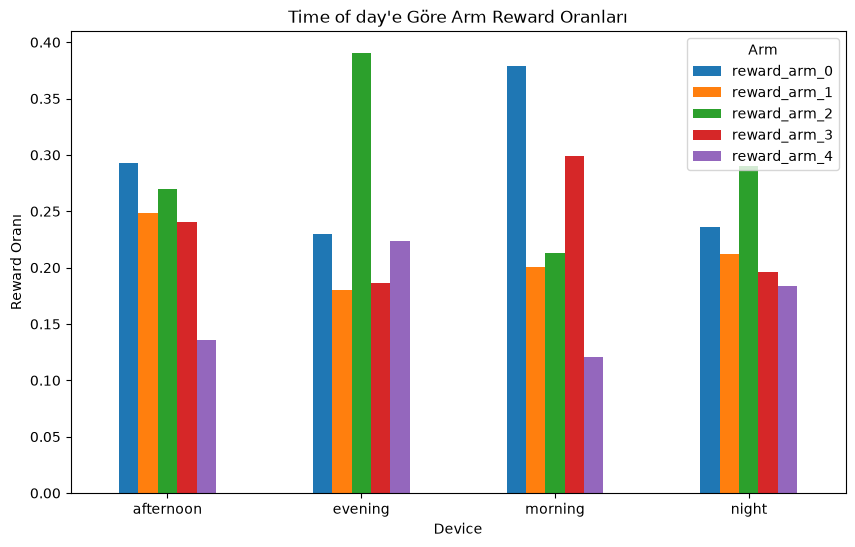

In [17]:
device_reward = df.groupby("time_of_day")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

device_reward.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Device")
plt.ylabel("Reward Oranı")
plt.title("Time of day'e Göre Arm Reward Oranları")
plt.xticks(rotation=0)
plt.legend(title="Arm")

plt.show()

             reward_arm_0  reward_arm_1  reward_arm_2  reward_arm_3  \
time_of_day                                                           
afternoon        0.092369      0.216867      0.502008      0.128514   
evening          0.060484      0.125000      0.673387      0.080645   
morning          0.156118      0.139241      0.459916      0.164557   
night            0.094737      0.157895      0.547368      0.063158   

             reward_arm_4  
time_of_day                
afternoon        0.196787  
evening          0.427419  
morning          0.181435  
night            0.315789  


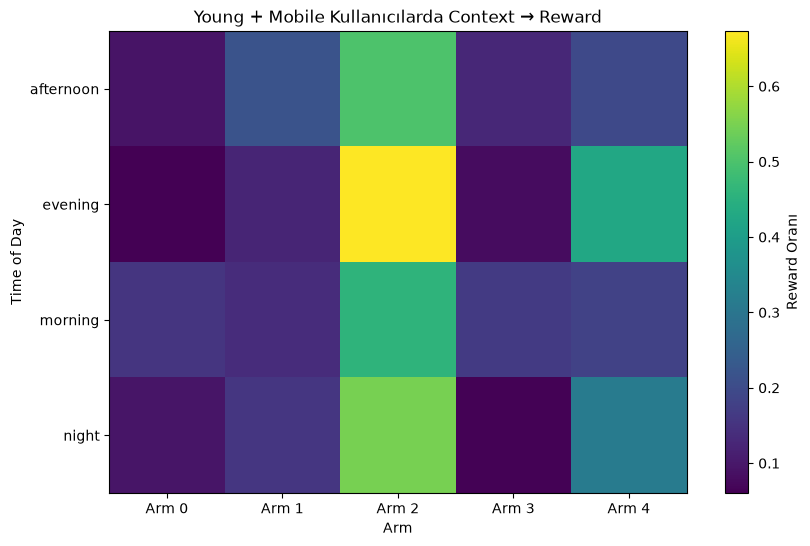

In [18]:
import matplotlib.pyplot as plt

# 1. Yaş gruplarını oluştur
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Older"]
)

# 2. Sadece Young + Mobile kullanıcılarını al
young_mobile = df[
    (df["age_group"] == "Young") &
    (df["device"] == "mobile")
]

# 3. Günün saatine göre reward oranlarını hesapla
reward_table = young_mobile.groupby("time_of_day")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

# 4. Tabloyu yazdır
print(reward_table)

# 5. Heatmap oluştur
plt.figure(figsize=(10, 6))

plt.imshow(reward_table)

plt.xticks(
    range(5),
    ["Arm 0", "Arm 1", "Arm 2", "Arm 3", "Arm 4"]
)

plt.yticks(
    range(len(reward_table)),
    reward_table.index
)

plt.xlabel("Arm")
plt.ylabel("Time of Day")
plt.title("Young + Mobile Kullanıcılarda Context → Reward")

plt.colorbar(label="Reward Oranı")

plt.show()

             reward_arm_0  reward_arm_1  reward_arm_2  reward_arm_3  \
time_of_day                                                           
afternoon        0.130982      0.289673      0.327456      0.216625   
evening          0.069231      0.212821      0.551282      0.225641   
morning          0.205729      0.200521      0.312500      0.250000   
night            0.107143      0.208333      0.357143      0.190476   

             reward_arm_4  
time_of_day                
afternoon        0.204030  
evening          0.351282  
morning          0.156250  
night            0.208333  


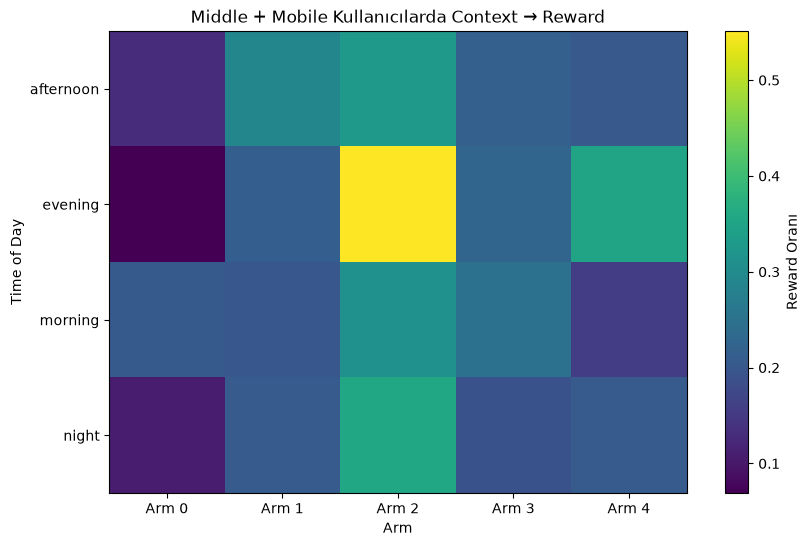

In [19]:
# 2. Sadece Young + Mobile kullanıcılarını al
young_mobile = df[
    (df["age_group"] == "Middle") &
    (df["device"] == "mobile")
]

# 3. Günün saatine göre reward oranlarını hesapla
reward_table = young_mobile.groupby("time_of_day")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

# 4. Tabloyu yazdır
print(reward_table)

# 5. Heatmap oluştur
plt.figure(figsize=(10, 6))

plt.imshow(reward_table)

plt.xticks(
    range(5),
    ["Arm 0", "Arm 1", "Arm 2", "Arm 3", "Arm 4"]
)

plt.yticks(
    range(len(reward_table)),
    reward_table.index
)

plt.xlabel("Arm")
plt.ylabel("Time of Day")
plt.title("Middle + Mobile Kullanıcılarda Context → Reward")

plt.colorbar(label="Reward Oranı")

plt.show()

             reward_arm_0  reward_arm_1  reward_arm_2  reward_arm_3  \
time_of_day                                                           
afternoon        0.305882      0.200000      0.289412      0.197647   
evening          0.262626      0.159091      0.421717      0.126263   
morning          0.353723      0.180851      0.207447      0.220745   
night            0.300000      0.168750      0.293750      0.181250   

             reward_arm_4  
time_of_day                
afternoon        0.174118  
evening          0.242424  
morning          0.140957  
night            0.193750  


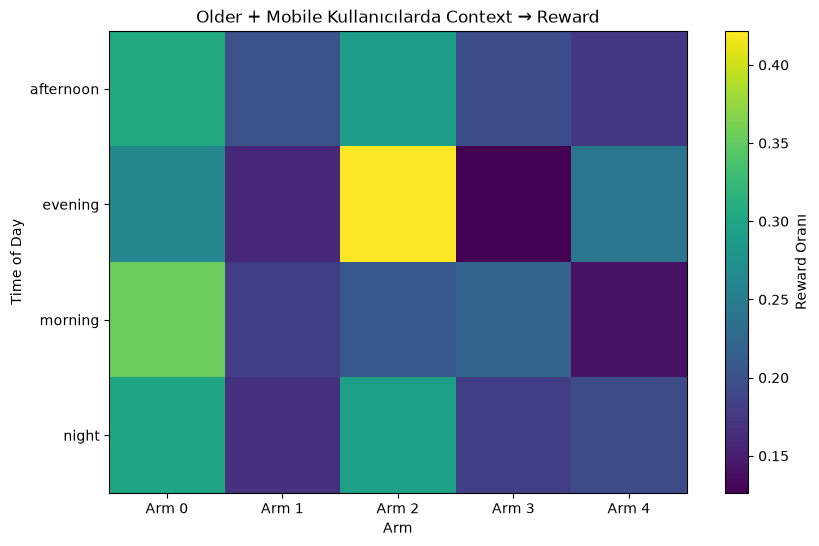

In [20]:
# 2. Sadece Young + Mobile kullanıcılarını al
young_mobile = df[
    (df["age_group"] == "Older") &
    (df["device"] == "mobile")
]

# 3. Günün saatine göre reward oranlarını hesapla
reward_table = young_mobile.groupby("time_of_day")[
    [
        "reward_arm_0",
        "reward_arm_1",
        "reward_arm_2",
        "reward_arm_3",
        "reward_arm_4"
    ]
].mean()

# 4. Tabloyu yazdır
print(reward_table)

# 5. Heatmap oluştur
plt.figure(figsize=(10, 6))

plt.imshow(reward_table)

plt.xticks(
    range(5),
    ["Arm 0", "Arm 1", "Arm 2", "Arm 3", "Arm 4"]
)

plt.yticks(
    range(len(reward_table)),
    reward_table.index
)

plt.xlabel("Arm")
plt.ylabel("Time of Day")
plt.title("Older + Mobile Kullanıcılarda Context → Reward")

plt.colorbar(label="Reward Oranı")

plt.show()

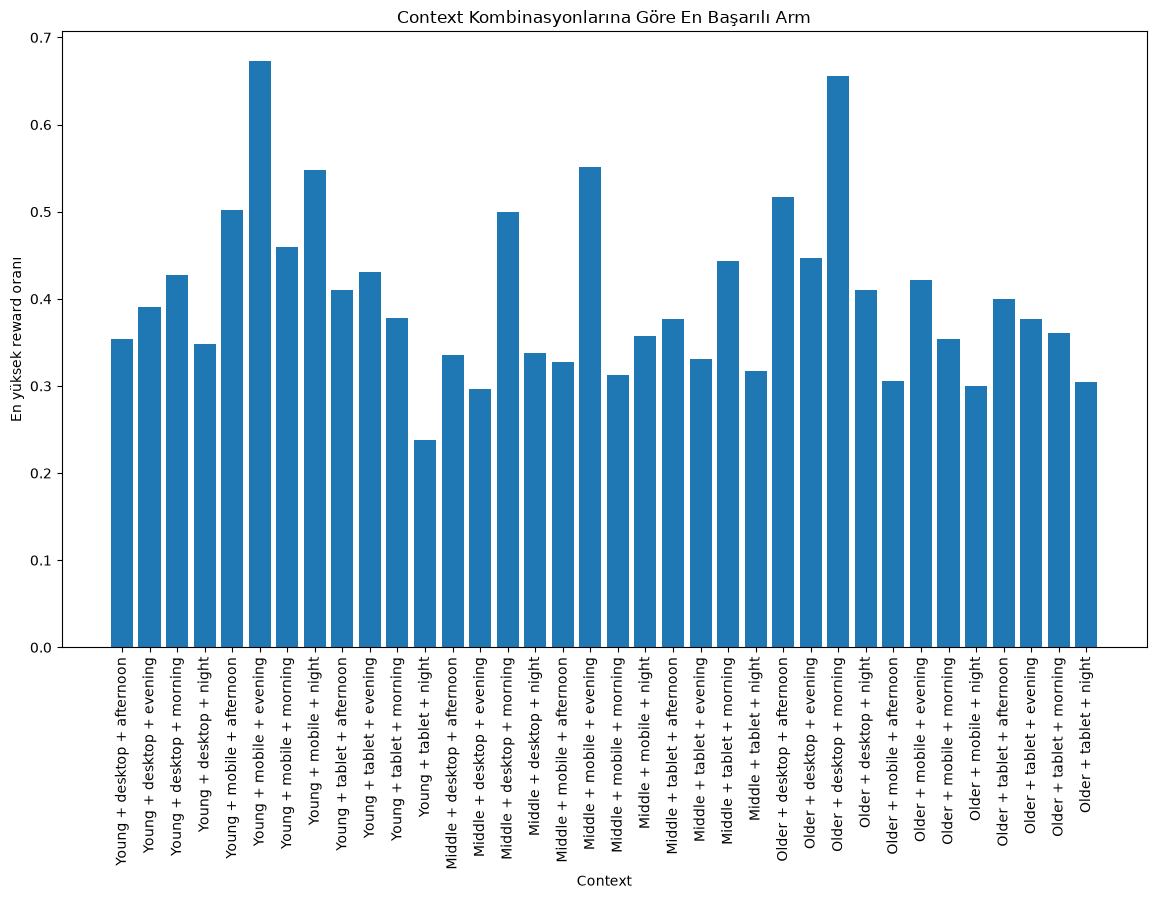

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Yaş grubu
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 50, 100],
    labels=["Young", "Middle", "Older"]
)

# Context gruplarına göre reward oranları
reward_table = df.groupby(
    ["age_group", "device", "time_of_day"],
    observed=True
)[[
    "reward_arm_0",
    "reward_arm_1",
    "reward_arm_2",
    "reward_arm_3",
    "reward_arm_4"
]].mean()

# Her context için en başarılı arm
best_arm = reward_table.idxmax(axis=1)

# Her context için en yüksek reward
best_reward = reward_table.max(axis=1)

# Grafik için tablo
plot_data = pd.DataFrame({
    "context": [
        f"{age} + {device} + {time}"
        for age, device, time in reward_table.index
    ],
    "best_arm": best_arm.values,
    "reward": best_reward.values
})

# Grafik
plt.figure(figsize=(14, 8))

plt.bar(
    plot_data["context"],
    plot_data["reward"]
)

plt.xlabel("Context")
plt.ylabel("En yüksek reward oranı")
plt.title("Context Kombinasyonlarına Göre En Başarılı Arm")

plt.xticks(rotation=90)

plt.show()